In [1]:
import biom
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import biom_to_csv as btc

In [2]:
#function x sample dataset
func_table = biom.load_table('functional_table_final.biom')
df_func = func_table.to_dataframe(dense=True)
X_sf = df_func.T

In [3]:
#describe dataset
funzioni_per_campione = (X_sf > 0).sum(axis=1)
print('Funzioni per campione:')
print(funzioni_per_campione.describe())

campioni_per_funzione = (X_sf > 0).sum(axis=0)
print('\nFunzioni più comuni:')
print(campioni_per_funzione.sort_values(ascending=False).head(20))

X_sf_clean = X_sf.loc[:, (X_sf > 0).any(axis=0)]
print(f'\nFunzioni con almeno 1 presenza: {X_sf_clean.shape[1]} su {X_sf.shape[1]}')

Funzioni per campione:
count    17483.000000
mean        29.832981
std         15.996783
min          0.000000
25%         16.000000
50%         29.000000
75%         43.000000
max         76.000000
dtype: float64

Funzioni più comuni:
chemoheterotrophy                17389
aerobic_chemoheterotrophy        17064
fermentation                     16846
nitrate_reduction                15462
animal_parasites_or_symbionts    14623
chloroplasts                     12747
nitrogen_respiration             12076
methylotrophy                    12063
phototrophy                      11959
intracellular_parasites          11951
nitrate_respiration              11925
human_associated                 11813
methanol_oxidation               11396
human_pathogens_all              11261
ureolysis                        11136
photoheterotrophy                10570
nitrite_respiration              10550
aromatic_compound_degradation    10425
hydrocarbon_degradation          10148
photoautotrophy        

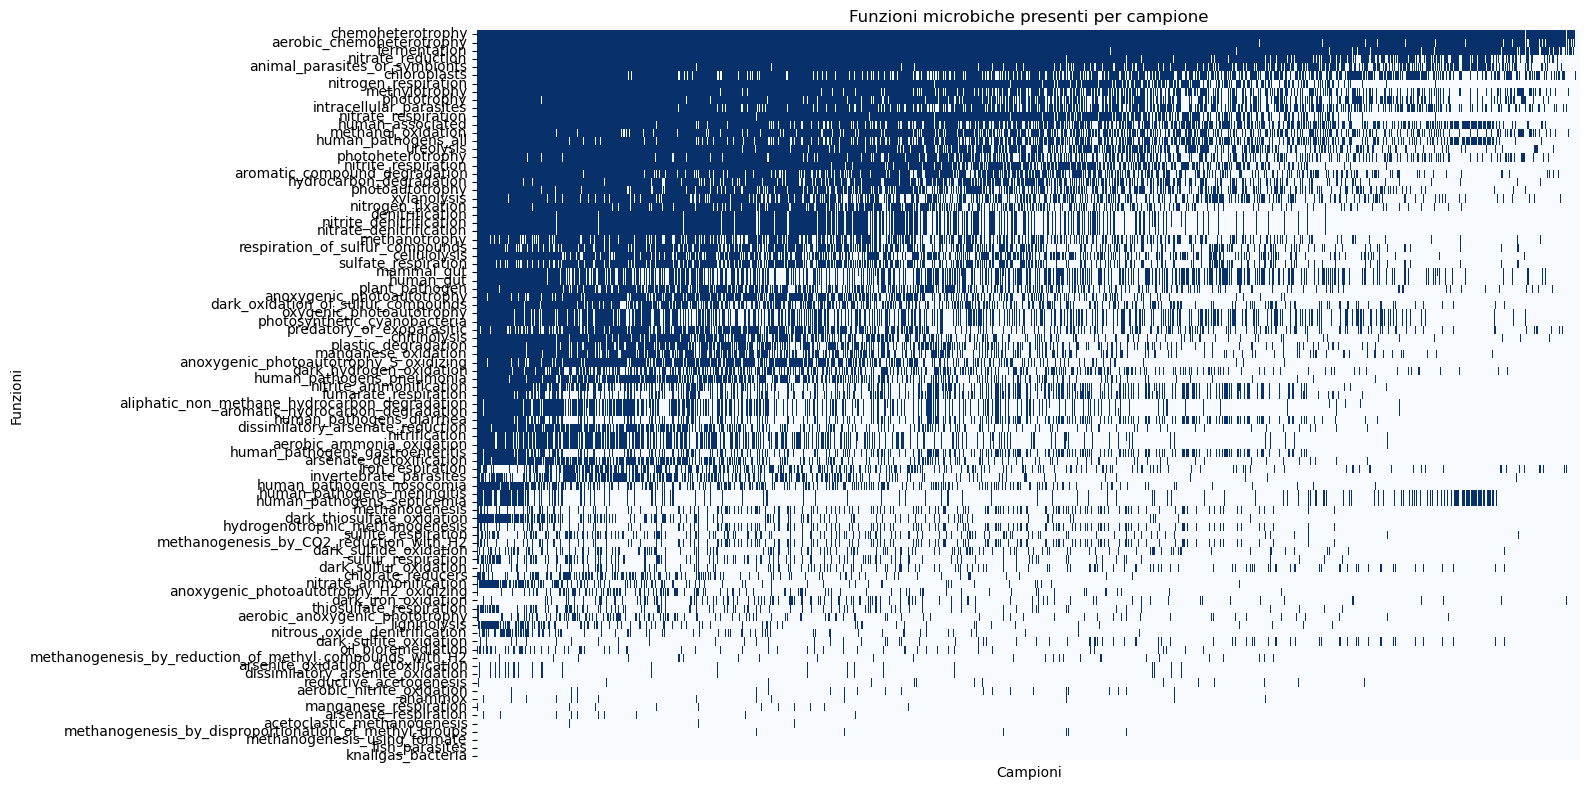

In [4]:
X_sf_bin = (X_sf_clean > 0).astype(int)

funz_order = X_sf_bin.sum(axis=0).sort_values(ascending=False).index
camp_order = X_sf_bin.sum(axis=1).sort_values(ascending=False).index

X_sf_sorted = X_sf_bin.loc[camp_order, funz_order]

plt.figure(figsize=(16, 8))
sns.heatmap(X_sf_sorted.T, 
            cmap='Blues',
            cbar=False,
            xticklabels=False,
            yticklabels=True)
plt.title('Funzioni microbiche presenti per campione')
plt.xlabel('Campioni')
plt.ylabel('Funzioni')
plt.tight_layout()
#plt.savefig('functional_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlazione entropia funzionale entropia tassonomica

In [5]:
#calculate bare entropies function entropy and sample entropy (functions)
Hf, Hsf = btc.entropy(X_sf)
print('Entropia funzioni')
print(Hf[:5])
print('Entropia sample')
print(Hsf[:5])

Entropia funzioni
methanotrophy                                            387.427647
acetoclastic_methanogenesis                                0.445251
methanogenesis_by_disproportionation_of_methyl_groups      0.530951
methanogenesis_using_formate                               0.010556
methanogenesis_by_CO2_reduction_with_H2                   35.933532
dtype: float64
Entropia sample
2229.S2.N22.EH1.Thomas.CMB.Seaweed.lane6.NoIndex.L006     0.001802
1883.2008.034.Crump.Artic.LTREB.main.lane2.NoIndex        0.000254
864.OTC.R.6.2009a.lane2.NoIndex                           0.099694
1883.2005.031.Crump.Artic.LTREB.main.lane1.NoIndex        0.000310
2229.W1.N2.4.HP4.Thomas.CMB.Seaweed.lane5.NoIndex.L005    0.001847
dtype: float64


In [6]:
X_sb   = btc.biom_to_csv_phylum('emp_deblur_150bp.release1.biom')

In [7]:
#calculate bare entropies phyla entropy and sample entropy (taxonomic)
Hp, Hsp = btc.entropy(X_sb)
print('Entropia phyla')
print(Hp[:5])
print('Entropia sample')
print(Hsp[:5])

Entropia phyla
p__Proteobacteria    5067.191767
p__Cyanobacteria     1685.502961
p__Bacteroidetes     3758.474607
p__TM6                 58.231568
p__Firmicutes        2206.842513
dtype: float64
Entropia sample
2229.S2.N22.EH1.Thomas.CMB.Seaweed.lane6.NoIndex.L006     0.012570
1883.2008.034.Crump.Artic.LTREB.main.lane2.NoIndex        0.000284
864.OTC.R.6.2009a.lane2.NoIndex                           0.107145
1883.2005.031.Crump.Artic.LTREB.main.lane1.NoIndex        0.000034
2229.W1.N2.4.HP4.Thomas.CMB.Seaweed.lane5.NoIndex.L005    0.002106
dtype: float64


In [8]:
df_scatter = pd.DataFrame({
    'H_phylum': Hsp,
    'H_funzioni': Hsf
}).dropna()

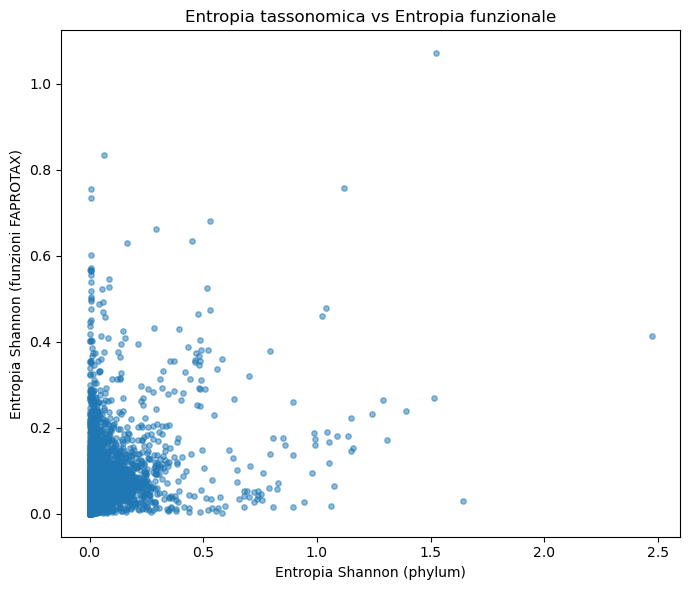

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(df_scatter['H_phylum'], df_scatter['H_funzioni'],
           alpha=0.5, s=15)

ax.set_xlabel('Entropia Shannon (phylum)')
ax.set_ylabel('Entropia Shannon (funzioni FAPROTAX)')
ax.set_title('Entropia tassonomica vs Entropia funzionale')

plt.tight_layout()
#plt.savefig('entropia_phylum_vs_funzioni.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
#align metadata to dataset (sample x phyla)
meta = pd.read_csv('emp_qiime_mapping_release1.tsv', sep='\t', index_col=0, low_memory=False)
meta_filtered = meta.loc[meta.index.isin(X_sb.index)]
meta_aligned = meta_filtered.reindex(X_sb.index)

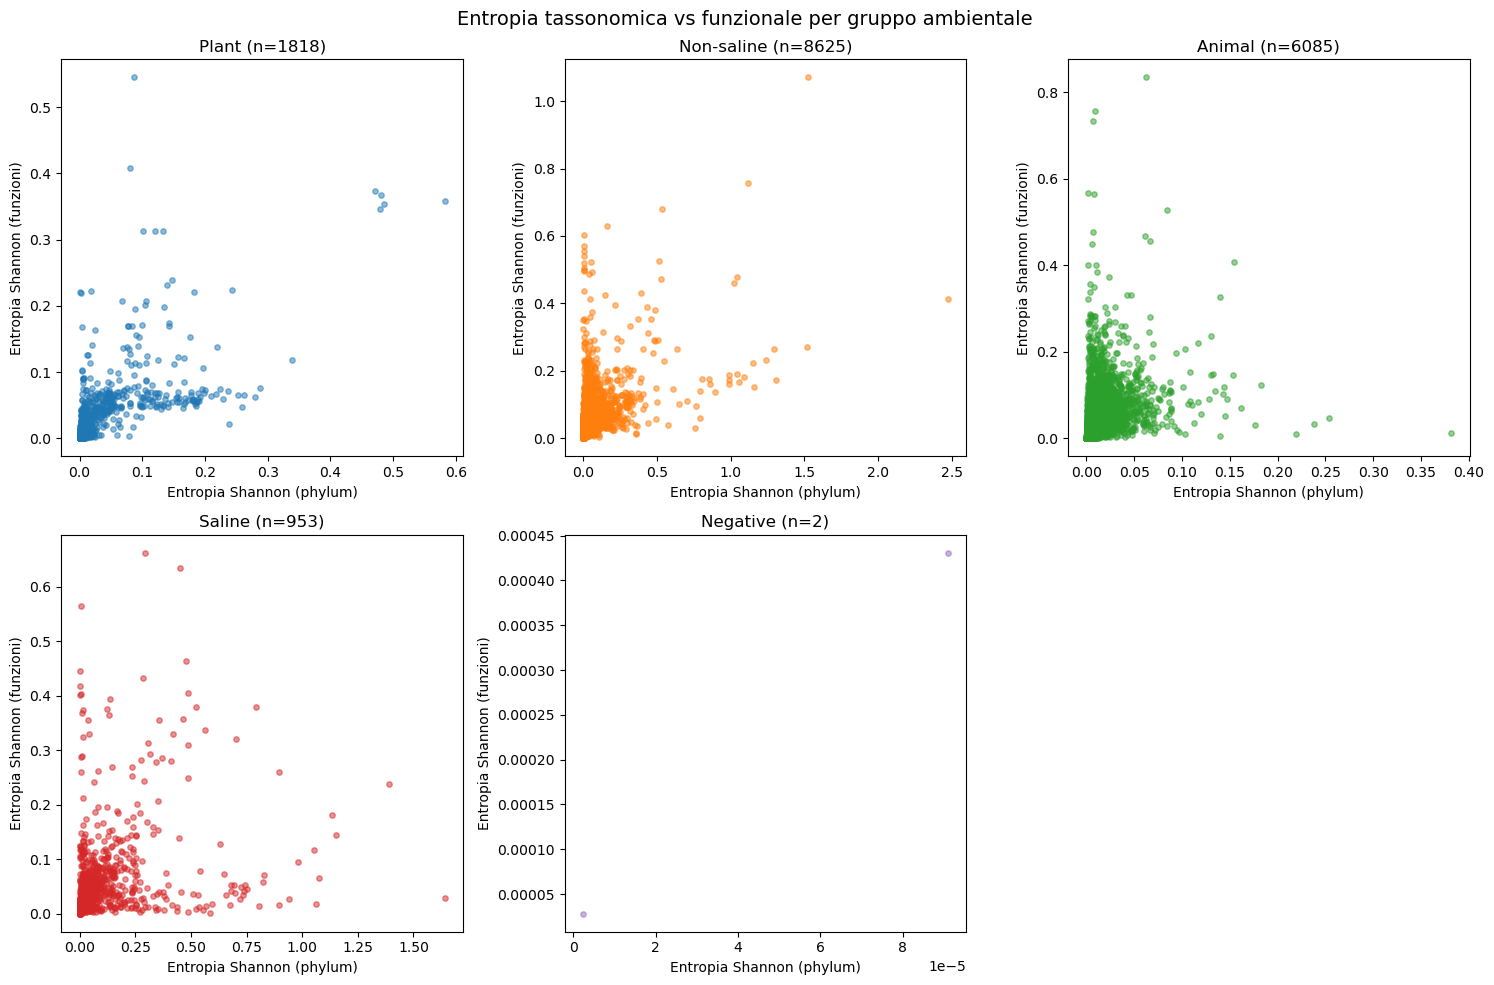

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

gruppi = meta_aligned.loc[df_scatter.index, 'empo_2'].dropna().unique()
colors = plt.cm.tab10(range(len(gruppi)))

for idx, (gruppo, color) in enumerate(zip(gruppi, colors)):
    
    ids_gruppo = meta_aligned[meta_aligned['empo_2'] == gruppo].index
    subset = df_scatter.loc[df_scatter.index.isin(ids_gruppo)]
    
    axes[idx].scatter(subset['H_phylum'], subset['H_funzioni'],
                      c=[color], alpha=0.5, s=15)
    
    axes[idx].set_xlabel('Entropia Shannon (phylum)')
    axes[idx].set_ylabel('Entropia Shannon (funzioni)')
    axes[idx].set_title(f'{gruppo} (n={len(subset)})')

for idx in range(len(gruppi), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Entropia tassonomica vs funzionale per gruppo ambientale', fontsize=14)
plt.tight_layout()
#plt.savefig('entropia_per_gruppo.png', dpi=150, bbox_inches='tight')
plt.show()

##### in questi grafici le entropie sono state calcolate su tutto il dataset non per singolo gruppo

In [12]:
#align metadata to dataset (sample x function)
meta_filtered_f = meta.loc[meta.index.isin(X_sf.index)]
meta_aligned_f = meta_filtered.reindex(X_sf.index)

In [13]:
gruppi = {}
for gruppo in meta_aligned['empo_2'].unique():
    mask = meta_aligned['empo_2'] == gruppo
    gruppi[gruppo] = X_sb[mask]
    print(f"{gruppo}: {gruppi[gruppo].shape}")
gruppi.pop("Negative")

Plant: (1818, 81)
Non-saline: (8625, 81)
Animal: (6085, 81)
Saline: (953, 81)
Negative: (2, 81)


,p__Proteobacteria,p__Cyanobacteria,p__Bacteroidetes,p__TM6,p__Firmicutes,p__Chloroflexi,p__Unknown,p__Armatimonadetes,p__Gemmatimonadetes,p__OP3,...,p__OP1,p__TPD-58,p__AncK6,p__H-178,p__Caldiserica,p__OC31,p__Aquificae,p__OctSpA1-106,p__VHS-B3-43,p__Thermotogae
1883.empty.well.2.Crump.Artic.LTREB.main.lane4.NoIndex,3.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1883.vacant.Crump.Artic.LTREB.main.lane1.NoIndex,159.0,0.0,36.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
gruppi_f = {}
for gruppo in meta_aligned_f['empo_2'].unique():
    mask = meta_aligned_f['empo_2'] == gruppo
    gruppi_f[gruppo] = X_sf[mask]
    print(f"{gruppo}: {gruppi_f[gruppo].shape}")
gruppi_f.pop("Negative")

Plant: (1818, 92)
Non-saline: (8625, 92)
Animal: (6085, 92)
Saline: (953, 92)
Negative: (2, 92)


,methanotrophy,acetoclastic_methanogenesis,methanogenesis_by_disproportionation_of_methyl_groups,methanogenesis_using_formate,methanogenesis_by_CO2_reduction_with_H2,methanogenesis_by_reduction_of_methyl_compounds_with_H2,hydrogenotrophic_methanogenesis,methanogenesis,methanol_oxidation,methylotrophy,...,anoxygenic_photoautotrophy,oxygenic_photoautotrophy,photoautotrophy,aerobic_anoxygenic_phototrophy,photoheterotrophy,phototrophy,plastic_degradation,ureolysis,reductive_acetogenesis,chemoheterotrophy
1883.empty.well.2.Crump.Artic.LTREB.main.lane4.NoIndex,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
1883.vacant.Crump.Artic.LTREB.main.lane1.NoIndex,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0,49.0,...,0.0,0.0,0.0,0.0,8.0,8.0,0.0,0.0,0.0,66.0


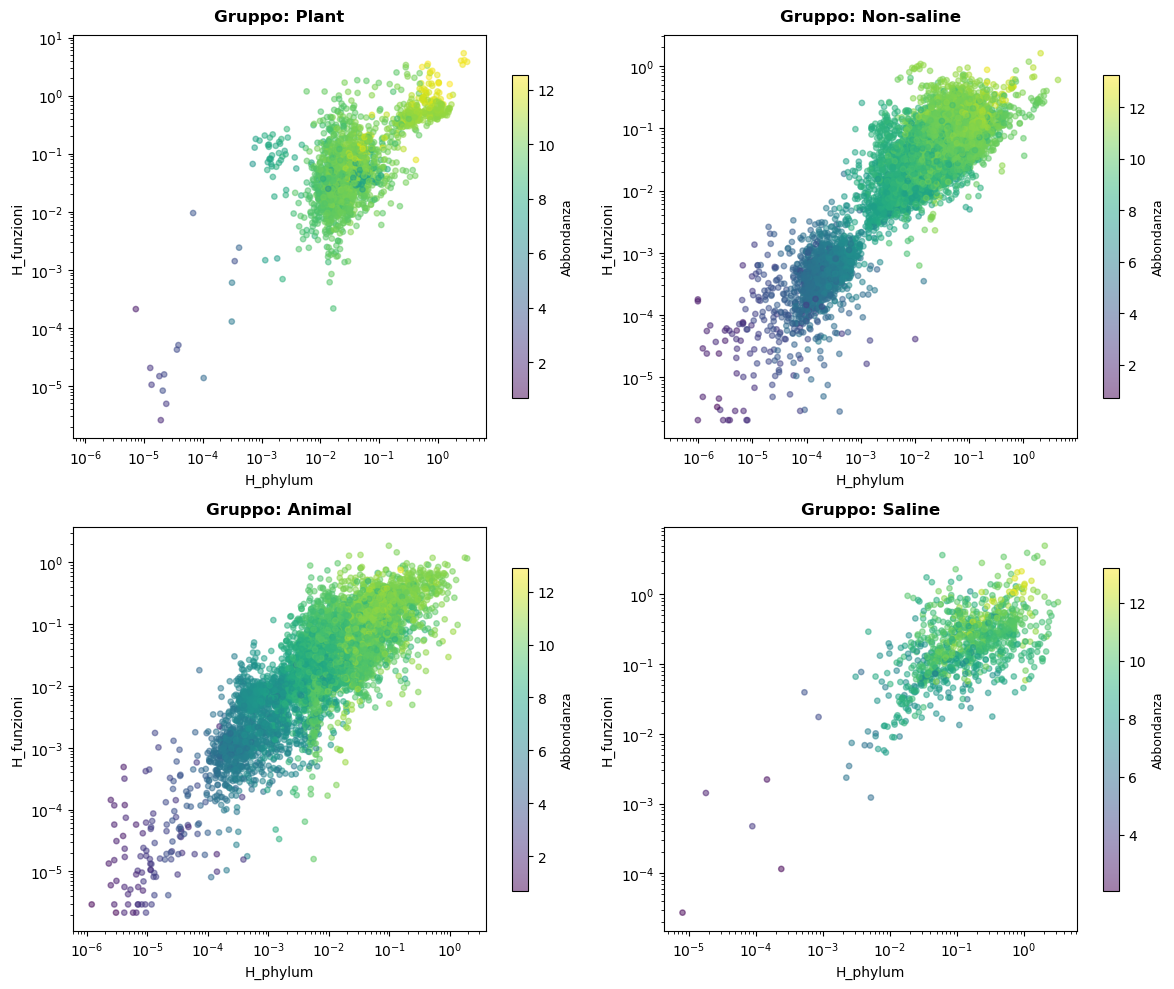

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, gruppo in enumerate(gruppi.keys()):
    ax = axes[i]

    Hpf, Hsf = btc.entropy(gruppi_f[gruppo])
    Hp, Hs = btc.entropy(gruppi[gruppo])
    abbondanza = np.log(gruppi[gruppo].sum(axis=1))
    
    df_scatter_sing = pd.DataFrame({
        'H_phylum': Hs,
        'H_funzioni': Hsf,
        'abbondanza' : abbondanza
    }).dropna()

    sc = ax.scatter(df_scatter_sing['H_phylum'], df_scatter_sing['H_funzioni'], alpha=0.5, s=15, c=df_scatter_sing['abbondanza'], cmap='viridis')

    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.set_xlabel('H_phylum', fontsize=10)
    ax.set_ylabel('H_funzioni', fontsize=10)
    ax.set_title(f'Gruppo: {gruppo}', fontsize=12, fontweight='bold', pad=10)

    cbar = fig.colorbar(sc, ax=ax, shrink=0.8)
    cbar.set_label('log Abbondanza', fontsize=9)

plt.tight_layout()
plt.show()

##### in questi grafici le entropie sono state calcolate rispetto al singolo gruppo e non sull'intero dataset

# Rifaccio i grafici utilizzando la funzione relativa all'abbondanza dei phyla che svolgono tale funzione nel campione

In [16]:
#build otu dictionary
df_otu2func = pd.read_csv(
    'otu2func_final.tsv',
    sep='\t',
    header=None,
    names=['otu_id', 'functions', 'taxonomy'],
    dtype=str,
    keep_default_na=False,
)
df_otu2func = df_otu2func.set_index('otu_id')
print('otu2func.tsv caricato:', df_otu2func.shape)

otu2func = {}
for otu_id, row in df_otu2func.iterrows():
    funcs = row['functions']
    otu2func[otu_id] = [] if funcs == '' else [f.strip() for f in funcs.split(',')]

n_with_func = sum(1 for v in otu2func.values() if v)
print(f'OTU totali: {len(otu2func)}, con almeno una funzione: {n_with_func}')

otu2func.tsv caricato: (197712, 2)
OTU totali: 197712, con almeno una funzione: 47190


In [17]:
#otu to phylum
table_otu = biom.load_table('emp_deblur_150bp.release1.biom') 
otu2phylum = {}
for otu_id in table_otu.ids(axis='observation'):
    meta = table_otu.metadata(otu_id, axis='observation')
    otu2phylum[otu_id] = btc.get_phylum(otu_id, meta)

print(f'OTU nel biom originale: {len(otu2phylum)}')

ids_func = set(otu2func.keys())
ids_biom = set(otu2phylum.keys())
print(f'In comune: {len(ids_func & ids_biom)}')
print(f'Solo in otu2func: {len(ids_func - ids_biom)}')
print(f'Solo nel biom: {len(ids_biom - ids_func)}')


OTU nel biom originale: 197711
In comune: 197711
Solo in otu2func: 1
Solo nel biom: 0


In [18]:
#define phylum x function binary matrix
records = []
for otu_id, funcs in otu2func.items():
    phylum = otu2phylum.get(otu_id, 'p__Unknown')
    for f in funcs:
        records.append((phylum, f))

df_long = pd.DataFrame(records, columns=['phylum', 'function']).drop_duplicates()
df_long['present'] = 1

W = (df_long
     .pivot(index='phylum', columns='function', values='present')
     .fillna(0)
     .astype(int))

print('Matrice phylum x funzioni (W):', W.shape)


Matrice phylum x funzioni (W): (24, 415)


In [19]:
#load functional_table
table_func = biom.load_table('functional_table_final.biom')
F_sf = table_func.to_dataframe(dense=True).T   # righe=samples, colonne=funzioni
F_sf.index = F_sf.index.astype(str)
print('F_sf (grezza, da FAPROTAX):', F_sf.shape)


F_sf (grezza, da FAPROTAX): (17483, 92)


In [20]:
#define abundance
common_phyla = X_sb.columns.intersection(W.index)
print(f'Phyla in comune tra X_sb e W: {len(common_phyla)} / {X_sb.shape[1]}')

W_aligned = W.loc[common_phyla]
X_sb_aligned = X_sb[common_phyla]    # CONTROLLARE

A_sf = X_sb_aligned.dot(W_aligned)  
print('A_sf (n. phyla capaci per campione/funzione):', A_sf.shape)
print('Range A_sf:', A_sf.values.min(), '-', A_sf.values.max())


Phyla in comune tra X_sb e W: 24 / 81
A_sf (n. phyla capaci per campione/funzione): (17483, 415)
Range A_sf: 0.0 - 455898.0


In [21]:
#define sample x relative function matrix

common_samples = F_sf.index.intersection(A_sf.index)
common_functions = F_sf.columns.intersection(A_sf.columns)
print(f'Campioni in comune: {len(common_samples)} / {F_sf.shape[0]}')
print(f'Funzioni in comune: {len(common_functions)} / {F_sf.shape[1]}')

F_sf_aligned = F_sf.loc[common_samples, common_functions]
A_sf_aligned = A_sf.loc[common_samples, common_functions]


Campioni in comune: 17483 / 17483
Funzioni in comune: 68 / 92


In [22]:
X_sf_rel = F_sf_aligned.divide(A_sf_aligned.replace(0, np.nan))
X_sf_rel = X_sf_rel.fillna(0)

In [23]:
meta = pd.read_csv('emp_qiime_mapping_release1.tsv', sep='\t', index_col=0, low_memory=False)
meta_filtered_frel = meta.loc[meta.index.isin(X_sf_rel.index)]
meta_aligned_frel = meta_filtered.reindex(X_sf_rel.index)

gruppi_frel = {}
for gruppo in meta_aligned_frel['empo_2'].unique():
    mask = meta_aligned_frel['empo_2'] == gruppo
    gruppi_frel[gruppo] = X_sf_rel[mask]
    print(f"{gruppo}: {gruppi_frel[gruppo].shape}")
gruppi_frel.pop("Negative")

Plant: (1818, 68)
Non-saline: (8625, 68)
Animal: (6085, 68)
Saline: (953, 68)
Negative: (2, 68)


,acetoclastic_methanogenesis,hydrogenotrophic_methanogenesis,methanogenesis,aerobic_ammonia_oxidation,aerobic_nitrite_oxidation,nitrification,dark_sulfite_oxidation,arsenate_detoxification,arsenate_respiration,dissimilatory_arsenate_reduction,...,anoxygenic_photoautotrophy_S_oxidizing,anoxygenic_photoautotrophy,photoautotrophy,aerobic_anoxygenic_phototrophy,photoheterotrophy,phototrophy,plastic_degradation,ureolysis,reductive_acetogenesis,chemoheterotrophy
1883.empty.well.2.Crump.Artic.LTREB.main.lane4.NoIndex,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.600000
1883.vacant.Crump.Artic.LTREB.main.lane1.NoIndex,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.050314,0.050314,0.0,0.0,0.0,0.193548


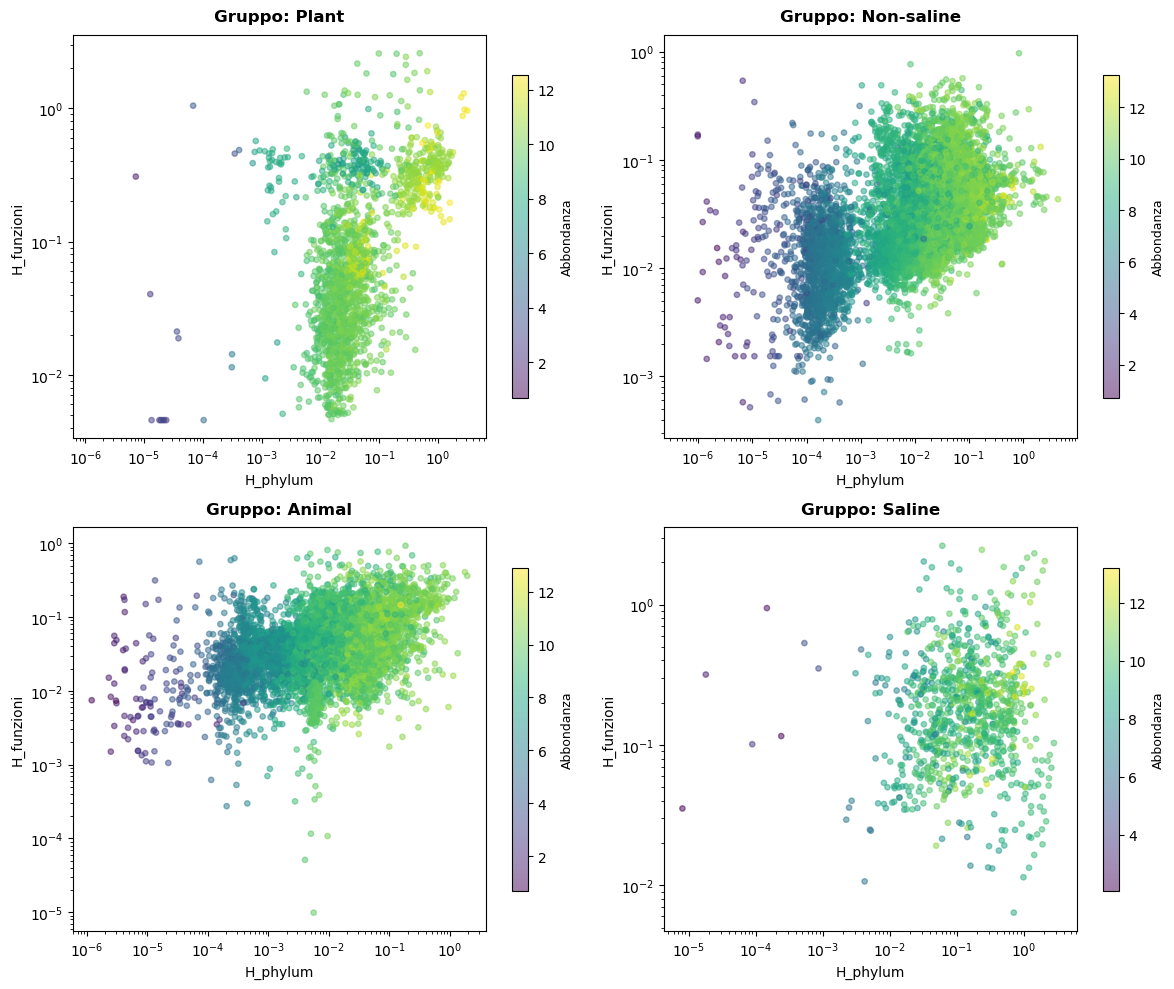

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, gruppo in enumerate(gruppi.keys()):
    ax = axes[i]

    Hpf, Hsf = btc.entropy(gruppi_frel[gruppo])
    Hp, Hs = btc.entropy(gruppi[gruppo])
    abbondanza = np.log(gruppi[gruppo].sum(axis=1))
    
    df_scatter_sing = pd.DataFrame({
        'H_phylum': Hs,
        'H_funzioni': Hsf,
        'abbondanza' : abbondanza
    }).dropna()

    sc = ax.scatter(df_scatter_sing['H_phylum'], df_scatter_sing['H_funzioni'], alpha=0.5, s=15, c=df_scatter_sing['abbondanza'], cmap='viridis')

    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.set_xlabel('H_phylum', fontsize=10)
    ax.set_ylabel('H_funzioni', fontsize=10)
    ax.set_title(f'Gruppo: {gruppo}', fontsize=12, fontweight='bold', pad=10)

    cbar = fig.colorbar(sc, ax=ax, shrink=0.8)
    cbar.set_label('Abbondanza', fontsize=9)

plt.tight_layout()
plt.show()